# Week 4 Assignment
## Welltory COVID-19 Data Exploration

The Welltory app allowed users to participate in a study that tracked how COVID-19 affected their bodies. 
The dataset combines Heart Rate Variability (HRV), data from wearable devices, self-reported symptoms and tests.

**Sampling and population:** Participants for the test volunteered for it so this is not a random sample. These individuals most likely already used the app and were more health conscious which likely skewed some of the results. 

Below are the features I used and focused on:
- `time_of_day`: part of the day(morning, day, evening, night) 
- `user_code`: anonymized particpant ID which links the hrv measurements to particpants
- `measurement_datetime`: When the HRV reading was taken
- `bpm`: Heart rate
- `rmssd`: Beat-to-beat variability; reflects parasympathetic ("rest and digest") activity and tends to drop during illness
- `sdnn`: Overall variability in time between heartbeats
- `how_feel`: Self-reported feeling at the time of the reading
- `age_range`: Participant's age bracket
- `symptoms_onset`: Date the participant's symptoms began 

The rest of the columns were different variations of the ones I used.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

data_dir = Path(r"C:\Users\gabes\Duke\week4\hrv-covid19\data")

In [2]:
for p in sorted(data_dir.iterdir()):
    size_kb = p.stat().st_size / 1024 if p.is_file() else 0
    print(f"{p.name}: {size_kb:.2f} KB")

blood_pressure.csv: 46.95 KB
heart_rate.csv: 21143.35 KB
hrv_measurements.csv: 2074.89 KB
participants.csv: 14.10 KB
scales_description.csv: 12.73 KB
sleep.csv: 43.89 KB
surveys.csv: 151.03 KB
wearables.csv: 315.53 KB
weather.csv: 130.07 KB


In [3]:
participants = pd.read_csv(data_dir / "participants.csv")
hrv = pd.read_csv(data_dir / "hrv_measurements.csv")

print("participants:", participants.shape)
print(participants.columns.tolist())
print()
print("hrv:", hrv.shape)
print(hrv.columns.tolist())

participants: (185, 8)
['user_code', 'gender', 'age_range', 'city', 'country', 'height', 'weight', 'symptoms_onset']

hrv: (3245, 22)
['user_code', 'rr_code', 'measurement_datetime', 'time_of_day', 'bpm', 'meanrr', 'mxdmn', 'sdnn', 'rmssd', 'pnn50', 'mode', 'amo', 'lf', 'hf', 'vlf', 'lfhf', 'total_power', 'how_feel', 'how_mood', 'how_sleep', 'tags', 'rr_data']


In [4]:
# Check units and ranges against what the documentation claims
hrv[["bpm", "meanrr", "sdnn", "rmssd", "pnn50", "lfhf"]].describe()

,bpm,meanrr,sdnn,rmssd,pnn50,lfhf
count,3245.000000,3245.000000,3245.000000,3245.000000,3245.000000,3245.000000
mean,73.257935,839.600366,52.489218,52.814196,20.615609,2.397769
std,12.201088,137.420367,29.369506,39.353213,18.588156,5.750760
min,44.000000,477.730000,9.515000,6.340000,0.000000,0.032000
25%,65.000000,742.490000,32.585000,28.985000,6.060000,0.399000
50%,72.000000,829.100000,46.919000,42.869000,16.160000,0.862000
75%,81.000000,925.933000,64.406000,62.485000,29.290000,1.966000
max,125.000000,1346.740000,206.631000,310.800000,91.920000,105.625000


In [5]:
# Discover the actual categories and rating scales
print(hrv["time_of_day"].value_counts(dropna=False), "\n")
print(hrv["how_feel"].value_counts(dropna=False).sort_index(), "\n")
print(participants["age_range"].value_counts(dropna=False), "\n")
print(hrv["tags"].head(10))


time_of_day
morning    1467
day         806
evening     701
night       271
Name: count, dtype: int64 

how_feel
-2     124
-1     857
 0    1975
 1     237
 2      52
Name: count, dtype: int64 

age_range
35-44    56
45-54    51
25-34    46
18-24    16
55-64     9
65-74     7
Name: count, dtype: int64 

0    COVID-19; Workout; Sex; Hobby; Studying; Sleep...
1                                                  NaN
2    COVID-19; Fast/Diet; Hungry; Tired; Fever; I c...
3                                                  NaN
4                                                  NaN
5                                                  NaN
6                                                  NaN
7                                                  NaN
8                                                  NaN
9                                                  NaN
Name: tags, dtype: object


## Quality Checks

In [6]:
hrv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3245 entries, 0 to 3244
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_code             3245 non-null   object 
 1   rr_code               3245 non-null   object 
 2   measurement_datetime  3245 non-null   object 
 3   time_of_day           3245 non-null   object 
 4   bpm                   3245 non-null   int64  
 5   meanrr                3245 non-null   float64
 6   mxdmn                 3245 non-null   float64
 7   sdnn                  3245 non-null   float64
 8   rmssd                 3245 non-null   float64
 9   pnn50                 3245 non-null   float64
 10  mode                  3245 non-null   float64
 11  amo                   3245 non-null   float64
 12  lf                    3245 non-null   float64
 13  hf                    3245 non-null   float64
 14  vlf                   3245 non-null   float64
 15  lfhf                 

In [7]:
print("participants missing values:")
print(participants.isna().sum())
print("hrv missing values:")
print(hrv.isna().sum())

participants missing values:
user_code          0
gender             0
age_range          0
city              12
country            6
height             2
weight             0
symptoms_onset    38
dtype: int64
hrv missing values:
user_code                  0
rr_code                    0
measurement_datetime       0
time_of_day                0
bpm                        0
meanrr                     0
mxdmn                      0
sdnn                       0
rmssd                      0
pnn50                      0
mode                       0
amo                        0
lf                         0
hf                         0
vlf                        0
lfhf                       0
total_power                0
how_feel                   0
how_mood                   0
how_sleep               1779
tags                    1044
rr_data                    0
dtype: int64


In [8]:
print("fully duplicated hrv rows:", hrv.duplicated().sum())
print("repeated rr_code values:", hrv["rr_code"].duplicated().sum())
print("repeated participant IDs:", participants["user_code"].duplicated().sum())

fully duplicated hrv rows: 0
repeated rr_code values: 0
repeated participant IDs: 0


In [9]:
orphans = ~hrv["user_code"].isin(participants["user_code"])
print("hrv rows with no matching participant:", orphans.sum())

hrv rows with no matching participant: 0


In [10]:
implied_rr = 60000 / hrv["bpm"]
pct_diff = ((hrv["meanrr"] - implied_rr) / implied_rr).abs()
print(pct_diff.describe())
print("rows where meanrr and bpm disagree by more than 10%:", (pct_diff > 0.1).sum())

count    3245.000000
mean        0.005709
std         0.005642
min         0.000003
25%         0.001993
50%         0.004506
75%         0.007825
max         0.043656
dtype: float64
rows where meanrr and bpm disagree by more than 10%: 0


In [11]:
per_user = hrv.groupby("user_code").size()
print(per_user.describe())
print("Participants with only 1 measurement:", (per_user == 1).sum())

count    185.000000
mean      17.540541
std       45.790517
min        1.000000
25%        1.000000
50%        4.000000
75%       12.000000
max      405.000000
dtype: float64
Participants with only 1 measurement: 54


In [12]:
# checking for the same person being recorded twice at the same moment under different codes

near_duplicates = hrv.duplicated(subset=["user_code", "measurement_datetime"]).sum()
print("Same participant, same timestamp:", near_duplicates)

Same participant, same timestamp: 0


In [13]:
print(participants['symptoms_onset'].head(10))
print(participants['symptoms_onset'].dtype)

0          NaN
1    5/15/2020
2     4/5/2020
3     5/6/2020
4    5/27/2020
5    3/27/2020
6          NaN
7          NaN
8    3/25/2020
9     4/1/2020
Name: symptoms_onset, dtype: object
object


In [14]:
# Is how_sleep only recorded for morning measurements?
pd.crosstab(hrv["time_of_day"], hrv["how_sleep"].notna(), margins=True)

how_sleep,False,True,All
time_of_day,,,
day,781,25,806
evening,701,0,701
morning,27,1440,1467
night,270,1,271
All,1779,1466,3245


Top 5 participants' share of all measurements: 38.2%
Participants with 5+ measurements: 85


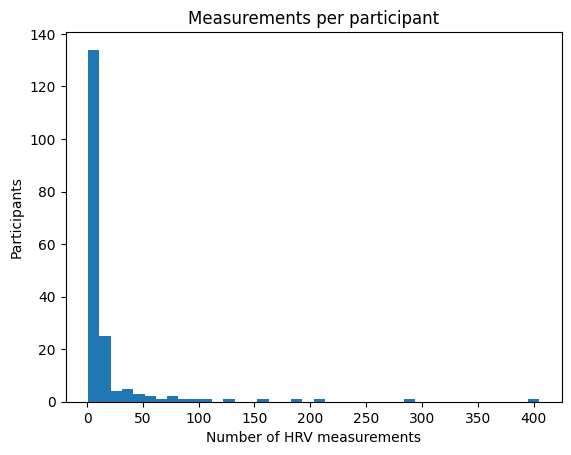

In [15]:
top = per_user.sort_values(ascending=False)
print("Top 5 participants' share of all measurements:",
      f"{top.head(5).sum() / top.sum():.1%}")
print("Participants with 5+ measurements:", (per_user >= 5).sum())

per_user.plot(kind="hist", bins=40, title="Measurements per participant")
plt.xlabel("Number of HRV measurements")
plt.ylabel("Participants")
plt.show()


## Data quality assessment

### Data Profiling
The HRV table itself had 3245 measurements, 185 participants, 22 columns. Given the measurements from the data, the collected statistics are dominated by a small number of active users. 

### Data Completeness
All the HRV metrics for HRV that I needed were available in the dataset. However, `how_sleep` is missing 55% because it's mostly recorded in the morning and `tags` is missing 32% because it's optional. symptoms_onset is missing for 38 of 185 participants." This could impact the synthesis but not by much.

### Data Accuracy
The data collected from the participants cannot be verified due to the sources that it was collected from. Some of the data points seem to be odd due to the fact that the data is collected differently from different devices. 

### Data Integrity
After doing some additional analysis, I was able to verify that there were no duplicated rows. There were no participants that had two measurements from the same timestamp for each unique ID. 

### Data Consistency
`meanrr` should be about 60,000 divided by bpm and the median difference was 0.45%. There were no rows off by more than 10%. This shows that the data in the columns is pretty consistent.

### Data Lineage and Provenance
The data was published by Welltory on GitHub (https://github.com/Welltory/hrv-covid19) under a CC0
public-domain license and collected through the Welltory app. The github link was then provided for the class in canvas assignment page.

# Cleaning and Transformation

In [16]:
hrv["measurement_datetime"] = pd.to_datetime(hrv["measurement_datetime"])
participants["symptoms_onset"] = pd.to_datetime(participants["symptoms_onset"], format="%m/%d/%Y")

print(hrv["measurement_datetime"].dtype, participants["symptoms_onset"].dtype)
print("measurements span:", hrv["measurement_datetime"].min(), "to", hrv["measurement_datetime"].max())

datetime64[ns] datetime64[ns]
measurements span: 2019-12-31 06:08:29 to 2020-06-19 11:40:13


In [17]:
# tag are optional
hrv["tags"] = hrv["tags"].fillna("")

# how sleep and symptoms onset are intentionally left missing
print("tags missing after fill:", hrv["tags"].isna().sum())
print("how_sleep missing:", hrv["how_sleep"].isna().sum())
print("symptoms_onset missing:", participants["symptoms_onset"].isna().sum())

tags missing after fill: 0
how_sleep missing: 1779
symptoms_onset missing: 38


In [18]:
df = hrv.merge(participants, on="user_code", how="left", validate=("many_to_one"))
print("merged shape:", df.shape)

merged shape: (3245, 29)


### Cleaning Decisions

- **Duplicates:** No rows were removed because all four duplicate checks found zero.
- **`tags`:** Were filled with an empty string because a missing tag means the user entered none, not     because the data was lost.
- **`how_sleep`:** Left missing, because the sleep question is tied to morning readings. Filling it would invent ratings that were never collected.
- **`symptoms_onset`:** Left missing, and those 38 participants were kept, because their HRV data is still valid. They are excluded only from analysis that depends on onset timing, since guessing an illness date would fabricate the timeline.
- **Dates:** `measurement_datetime` and `symptoms_onset` were converted from text to datetimes so they can be used in time based analysis.
- **Join:** The tables were merged on `user_code` with `validate="many_to_one"`, which would raise an error if any participant appeared twice. The merged table kept all 3,245 rows.


# Outliers

In [19]:
q1, q3 = df["rmssd"].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
lower = q1 - 1.5 * iqr

df["rmssd_outlier"] = (df["rmssd"] > upper) | (df["rmssd"] < lower)
print(f"IQR fences: {lower:.1f} to {upper:.1f} ms")
print("RMSSD outliers:", df["rmssd_outlier"].sum(), f"({df['rmssd_outlier'].mean():.1%})")

IQR fences: -21.3 to 112.7 ms
RMSSD outliers: 195 (6.0%)


## Second Plot

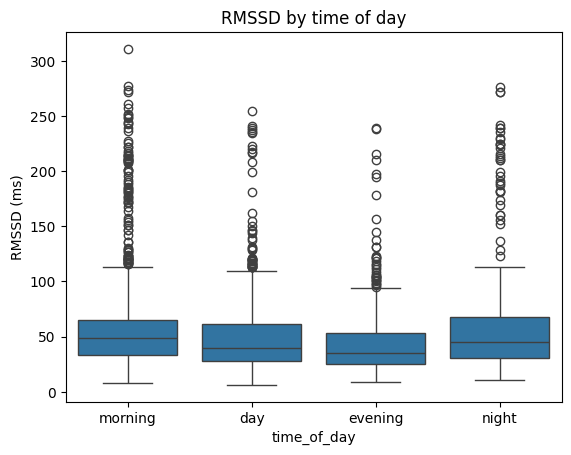

In [20]:
sns.boxplot(data=df, x="time_of_day", y="rmssd", order=["morning", "day", "evening", "night"])
plt.title("RMSSD by time of day")
plt.ylabel("RMSSD (ms)")
plt.show()

### Outlier Handling

RMSSD cannot be negative so there are no low outliers due to the fact that the lower fence is -21.3 ms. About 6% of the data, I considered as high outliers because they were over 112.7. 

I flagged these readings in the column instead of deleting them because sometimes high HRV can be a trait. Some fit, younger individuals have high HRV which is part of the reason this test was conducted, to test the fluctuations of the HRV level. 

### Correlation Heatmap

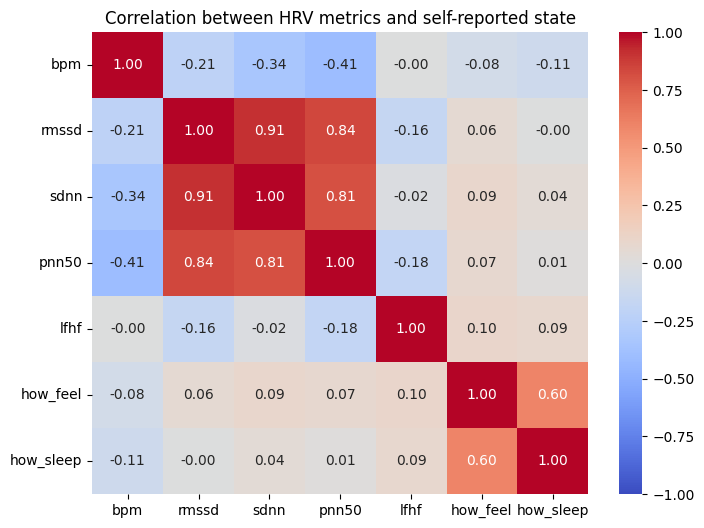

In [21]:
cols = ["bpm", "rmssd", "sdnn", "pnn50", "lfhf", "how_feel", "how_sleep"]
corr = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation between HRV metrics and self-reported state")
plt.show()

### RMSSD relative to personal baseline

In [22]:
baseline = df.groupby("user_code")["rmssd"].transform("median")
n_readings = df.groupby("user_code")["rmssd"].transform("size")

# 1.0 = normal for that person; 0.8 = 20% below their own normal
df["rmssd_vs_baseline"] = (df["rmssd"] / baseline).where(n_readings >= 5)

print(df["rmssd_vs_baseline"].describe())
print()
print("how_feel vs raw RMSSD:        ", round(df["rmssd"].corr(df["how_feel"]), 3))
print("how_feel vs RMSSD vs baseline:", round(df["rmssd_vs_baseline"].corr(df["how_feel"]), 3))

count    3071.000000
mean        1.097058
std         0.487285
min         0.127825
25%         0.787193
50%         1.000000
75%         1.264127
max         4.578111
Name: rmssd_vs_baseline, dtype: float64

how_feel vs raw RMSSD:         0.062
how_feel vs RMSSD vs baseline: 0.033


### Feature Explination

**Approach:** `rmssd_vs_baseline` divides each reading's RMSSD by that participant's median RMSSD. A value
of 1.0 means the reading is normal for that person, and 0.8 means it is 20% below their usual level.

**Why:** HRV varies widely between people, so raw RMSSD mostly shows who naturally has high HRV. Comparing
each reading to the person's own baseline isolates *changes*, which is what illness would be expected to
cause. I chose the median because it is not pulled upward by the 195 high outliers and I needed at least
5 readings. This leaves 3,071 readings from 85 participants that I used.

**Result:** The correlation between RMSSD and `how_feel` fell from 0.062 to 0.033. Removing differences between people did not reveal a hidden relationship that I thought there could be, so changes in HRV do not appear to track how participants say they feel.

## Conclusion

The HRV measurements collected are reliable and due to the fact that the data collected for bpm was in normal range and were no duplicated records the readings seem to be useable.

One limitation that I would like to call out is how the data was collected and which participants volunteered in the test. Due to the "technical" nature required for this testing, the individuals that volunteered for this were mostly middle aged and more health conscious. There were few older participants which could definitely skew the results gathered. In addition, some of the individuals had more readings that the other causing a small group of heavy users to sway the results of the testing. 

The correlation heatmap included above showed that the HRV metrics mostly measure the same thing. RMSSD correlated 0.91 with SDNN and 0.84 with pNN50, which is why I focused on RMSSD instead of analyzing every metric. Heart rate moved in the opposite direction from HRV (−0.21 to −0.41) which was expected. If I were to continue this research I would look into how `rmssd_vs_baseline` changes in the days around `symptoms_onset`. This would allow me to better understand the the illness timeline providing more insight into individuals reactions. 

After some of the other synthesis that I did, self-reporting does not reflect HRV changes since the correlation dropped from .06 to .03. There were about 61% of the responses that were neutral so that could also mean that the 5 point scale used to reflect on their feelings might not be accurate.

Given the rest of the information gathered, the HRV patterns could be accurately used for this population, however, would not be accurate for a more general population. 